In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from conf import cfg

from train_utils import testz
from loader_utils import *

In [2]:
cfg.VICTIM.ARCH = 'resnet18'
cfg.VICTIM.DATASET = 'CIFAR10'
cfg.VICTIM.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/'
cfg.VICTIM.PATH = '/home/ankita/mnt/data_msa_encoders/victims/victims_cifar10_lp/resnet18/checkpoint.pth.tar'
cfg.THIEF.ARCH = 'resnet18'
cfg.THIEF.DATASET = 'imagenet32'
cfg.THIEF.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/Imagenet32/train'

cfg.VICTIM.ARCH = 'resnet34'
cfg.VICTIM.DATASET = 'CIFAR10'
cfg.VICTIM.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/'
cfg.VICTIM.PATH = '/home/ankita/mnt/data_msa_encoders/victims/cifar10_resnet34_1k_224_0.002_lp/checkpoint.pth.tar'
cfg.THIEF.ARCH = 'resnet34'
cfg.THIEF.DATASET = 'imagenet32'
cfg.THIEF.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/Imagenet32/train'

cfg.VICTIM.ARCH = 'resnet50'
cfg.VICTIM.DATASET = 'CIFAR10'
cfg.VICTIM.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/'
cfg.VICTIM.PATH = '/home/ankita/mnt/data_msa_encoders/victims/cifar10_resnet50_1k_224_0.002_lp/checkpoint.pth.tar'
cfg.THIEF.ARCH = 'resnet50'
cfg.THIEF.DATASET = 'imagenet32'
cfg.THIEF.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/Imagenet32/train'

N = 10000
# classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = 10
M = 10000

In [3]:
# cfg.VICTIM.ARCH = 'resnet18'
# cfg.VICTIM.DATASET = 'Indoor67'
# cfg.VICTIM.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/'
# cfg.VICTIM.PATH = '/home/ankita/mnt/data_msa_encoders/victims/victims_indoor67_lp/resnet18/checkpoint.pth.tar'
# cfg.THIEF.ARCH = 'resnet18'
# cfg.THIEF.DATASET = 'imagenet_full'
# cfg.THIEF.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/Imagenet/ILSVRC/Data/CLS-LOC/train'

# cfg.VICTIM.ARCH = 'resnet34'
# cfg.VICTIM.DATASET = 'Indoor67'
# cfg.VICTIM.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/'
# cfg.VICTIM.PATH = '/home/ankita/mnt/data_msa_encoders/victims/victims_indoor67_lp/resnet34/checkpoint.pth.tar'
# cfg.THIEF.ARCH = 'resnet34'
# cfg.THIEF.DATASET = 'imagenet_full'
# cfg.THIEF.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/Imagenet/ILSVRC/Data/CLS-LOC/train'

# cfg.VICTIM.ARCH = 'resnet50'
# cfg.VICTIM.DATASET = 'Indoor67'
# cfg.VICTIM.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/'
# cfg.VICTIM.PATH = '/home/ankita/mnt/data_msa_encoders/victims/victims_indoor67_lp/resnet50/checkpoint.pth.tar'
# cfg.THIEF.ARCH = 'resnet50'
# cfg.THIEF.DATASET = 'imagenet_full'
# cfg.THIEF.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/Imagenet/ILSVRC/Data/CLS-LOC/train'

# cfg.VICTIM.ARCH = 'vit_s_16_21k'
# cfg.VICTIM.DATASET = 'Indoor67'
# cfg.VICTIM.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/'
# cfg.VICTIM.PATH = '/home/ankita/mnt/data_msa_encoders/victims/victims_indoor67_lp/vit_s_16_21k/checkpoint.pth.tar'
# cfg.THIEF.ARCH = 'vit_s_16_21k'
# cfg.THIEF.DATASET = 'imagenet_full'
# cfg.THIEF.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/Imagenet/ILSVRC/Data/CLS-LOC/train'

# cfg.VICTIM.ARCH = 'vit_b_16_21k'
# cfg.VICTIM.DATASET = 'Indoor67'
# cfg.VICTIM.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/'
# cfg.VICTIM.PATH = '/home/ankita/mnt/data_msa_encoders/victims/victims_indoor67_lp/vit_b_16_21k/checkpoint.pth.tar'
# cfg.THIEF.ARCH = 'vit_b_16_21k'
# cfg.THIEF.DATASET = 'imagenet_full'
# cfg.THIEF.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/Imagenet/ILSVRC/Data/CLS-LOC/train'

# cfg.VICTIM.ARCH = 'vit_l_16_21k'
# cfg.VICTIM.DATASET = 'Indoor67'
# cfg.VICTIM.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/'
# cfg.VICTIM.PATH = '/home/ankita/mnt/data_msa_encoders/victims/victims_indoor67_lp/vit_l_16_21k/checkpoint.pth.tar'
# cfg.THIEF.ARCH = 'vit_l_16_21k'
# cfg.THIEF.DATASET = 'imagenet_full'
# cfg.THIEF.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/Imagenet/ILSVRC/Data/CLS-LOC/train'

# N = 1340
# num_classes = 67
# M = 1340

In [4]:
cfg.VICTIM.ARCH = 'resnet50'
cfg.VICTIM.DATASET = 'Caltech256'
cfg.VICTIM.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/'
cfg.VICTIM.PATH = '/home/ankita/mnt/data_msa_encoders/victims/victims_caltech256_lp/resnet50/checkpoint.pth.tar'
cfg.THIEF.ARCH = 'resnet50'
cfg.THIEF.DATASET = 'imagenet_full'
cfg.THIEF.DATA_ROOT = '/home/ankita/mnt/vision03_datasets/Imagenet/ILSVRC/Data/CLS-LOC/train'

N = 6400
num_classes = 256
M = 6400

In [5]:
# Load victim dataset (test split only)
testset, victim_normalization_transform, n_classes = load_victim_dataset(cfg, cfg.VICTIM.DATASET, cfg.VICTIM.ARCH, img_size=224)
test_loader = DataLoader(testset, batch_size=128, num_workers=4, shuffle=False, pin_memory=False)  
print(f"Loaded target dataset of size {len(testset)} with {n_classes} classes")

modelfamily:  imagenet
dataset <class 'datasets.caltech256.Caltech256'>
=> done loading Caltech256 (test) with 6400 examples
Loaded target dataset of size 6400 with 256 classes


In [ ]:
# Load victim model        
target_model = load_victim_model(cfg.VICTIM.ARCH, cfg.VICTIM.PATH, cfg.VICTIM.LP, victim_normalization_transform, n_classes)

# Evaluate target model on target dataset: sanity check
acc, f1 = testz(target_model, test_loader)
print(f"Target model acc = {acc}")

Loaded target model /home/ankita/mnt/data_msa_encoders/victims/victims_caltech256_lp/resnet50/checkpoint.pth.tar
Target model acc = 0.5846875


In [7]:
class Thief(nn.Module):
    def __init__(self, model,input_size):
        super(Thief,self).__init__()
        self.model=model
        self.input_size=input_size
    def forward(self,x):
        x=torch.nn.functional.interpolate(x,size=(self.input_size, self.input_size), mode='bilinear', align_corners=False)
        out=self.model(x)
        return out

In [8]:
# Load pretrained model            
pretrained_model = load_thief_model(cfg, cfg.THIEF.ARCH, n_classes, cfg.ACTIVE.PRETRAINED_PATH)
pretrained_model = Thief(pretrained_model,cfg.THIEF.IMG_SIZE)
print("Thief model initialized successfully")
total_params = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {total_params}")

odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.0.conv3.weight', 'layer1.0.bn3.weight', 'layer1.0.bn3.bias', 'layer1.0.bn3.running_mean', 'layer1.0.bn3.running_var', 'layer1.0.bn3.num_batches_tracked', 'layer1.0.downsample.0.weight', 'layer1.0.downsample.1.weight', 'layer1.0.downsample.1.bias', 'layer1.0.downsample.1.running_mean', 'layer1.0.downsample.1.running_var', 'layer1.0.downsample.1.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.we

In [9]:
# ResNet
def feat_extractor(model, dataloader):
    model.eval()

    # a dict to store the activations
    activation = {}
    def getActivation(name):
        # the hook signature
        def hook(model, input, output):
            activation[name] = output.detach()
        return hook

    # register forward hooks on the layers of choice
    h1 = model.avgpool.register_forward_hook(getActivation('avgpool'))
    h2 = model.fc.register_forward_hook(getActivation('fc'))
    
    labels_vec = []
    avgpool_list =  []
    fc_list = []
    with torch.no_grad():
        for data in dataloader:
            inputs = data[0]
            labels = data[1]
            inputs = inputs.cuda()
            
            # forward pass -- getting the outputs
            out = model(inputs)
            
            # collect the activations in the correct list
            avgpool_list.extend(activation['avgpool'].cpu().numpy())
            fc_list.extend(activation['fc'].cpu().numpy())
                   
            labels_vec.extend(labels)

    # detach the hooks
    h1.remove()
    h2.remove()

    avgpool_list = np.asarray(avgpool_list)
    fc_list = np.asarray(fc_list)
    labels_vec = np.asarray(labels_vec)
    return avgpool_list, fc_list, labels_vec
    

In [10]:
# # ViT
# def feat_extractor(model, dataloader):
#     model.eval()

#     # a dict to store the activations
#     activation = {}
#     def getActivation(name):
#         # the hook signature
#         def hook(model, input, output):
#             activation[name] = output.detach()
#         return hook

#     # register forward hooks on the layers of choice
#     h1 = model.fc_norm.register_forward_hook(getActivation('fc_norm'))
#     h2 = model.head.register_forward_hook(getActivation('head'))
    
#     features = []
#     labels_vec = []
#     avgpool_list =  []
#     fc_list = []
#     with torch.no_grad():
#         for data in dataloader:
#             inputs = data[0]
#             labels = data[1]
#             inputs = inputs.cuda()

#             # feat = model(inputs)
#             # print(feat.shape)
#             # features.extend(feat.cpu().numpy())
            
#             # forward pass -- getting the outputs
#             out = model(inputs)
            
#             # collect the activations in the correct list
#             avgpool_list.extend(activation['fc_norm'].cpu().numpy())
#             fc_list.extend(activation['head'].cpu().numpy())
                   
#             labels_vec.extend(labels)

#     # detach the hooks
#     h1.remove()
#     h2.remove()

#     # features = np.asarray(features)
#     avgpool_list = np.asarray(avgpool_list)
#     fc_list = np.asarray(fc_list)
#     labels_vec = np.asarray(labels_vec)
#     return avgpool_list, fc_list, labels_vec
    

In [11]:
# Extract features of test data on pretrained model
avgpool_pretrained, _, y_pretrained = feat_extractor(pretrained_model.model, test_loader)
avgpool_pretrained = np.squeeze(avgpool_pretrained)
print('avgpool_pretrained: ', avgpool_pretrained.shape)

avgpool_pretrained:  (6400, 2048)


In [12]:
# Extract features of test data on target model
avgpool_victim, fc_victim, y_victim = feat_extractor(target_model.model, test_loader)
avgpool_victim = np.squeeze(avgpool_victim)
print('avgpool_victim: ', avgpool_victim.shape)

avgpool_victim:  (6400, 2048)


(6400, 2048)


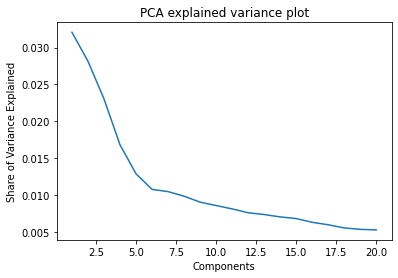

0.2265531732700765


In [13]:
# Pre-trained model
# standardize features by removing mean and scaling to unit variance
sc = StandardScaler()
X_rs = avgpool_pretrained.copy()
print(X_rs.shape)
X_rs = sc.fit_transform(X_rs)

# apply PCA
pca = PCA(n_components=20, whiten=True)
pca.fit(X_rs)

# extract the explained variance
explained_variance = pca.explained_variance_ratio_
singular_values = pca.singular_values_

# create an x for each component
x = np.arange(1,len(explained_variance)+1)

# plot the results
plt.plot(x, explained_variance)
plt.ylabel('Share of Variance Explained')
plt.title("PCA explained variance plot")
plt.xlabel("Components")
plt.show()
print(sum(explained_variance))

# tSNE embeddings
tsne = TSNE(perplexity=50).fit_transform(X_rs)
tx, ty = tsne[:,0], tsne[:,1]
tx1 = (tx-np.min(tx)) / (np.max(tx) - np.min(tx))
ty1 = (ty-np.min(ty)) / (np.max(ty) - np.min(ty))

In [14]:
# Victim model
# standardize features by removing mean and scaling to unit variance
sc = StandardScaler()
X_rs = fc_victim.copy()
print(X_rs.shape)
X_rs = sc.fit_transform(X_rs)

# # apply PCA
# pca = PCA(n_components=20, whiten=True)
# pca.fit(X_rs)

# # extract the explained variance
# explained_variance = pca.explained_variance_ratio_
# singular_values = pca.singular_values_

# # create an x for each component
# x = np.arange(1,len(explained_variance)+1)

# # plot the results
# plt.plot(x, explained_variance)
# plt.ylabel('Share of Variance Explained')
# plt.title("PCA explained variance plot")
# plt.xlabel("Components")
# plt.show()
# print(sum(explained_variance))

# tSNE embeddings
tsne = TSNE(perplexity=50).fit_transform(X_rs)
tx, ty = tsne[:,0], tsne[:,1]
tx2 = (tx-np.min(tx)) / (np.max(tx) - np.min(tx))
ty2 = (ty-np.min(ty)) / (np.max(ty) - np.min(ty))

(6400, 256)


No handles with labels found to put in legend.


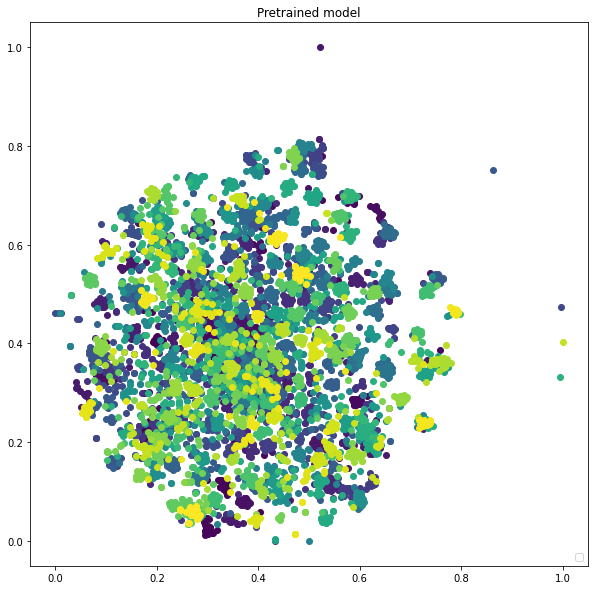

In [15]:
cmap = plt.get_cmap('viridis', num_classes)

# Pretrained model
tx_sub, ty_sub, y_test_sub = tx1, ty1, y_pretrained
tx_sub, ty_sub, y_test_sub = tx_sub[:M], ty_sub[:M], y_test_sub[:M]

fig = plt.figure(figsize=(10,10))
for i in range(num_classes):
    y_i = y_test_sub == i
    # plt.scatter(tx_sub[y_i[:]], ty_sub[y_i[:]], label=classes[i])
    plt.scatter(tx_sub[y_i[:]], ty_sub[y_i[:]], color=cmap(i / num_classes))
    
plt.title('Pretrained model')
# plt.xlim([-0.05, 0.45])
plt.legend(loc=4)

No handles with labels found to put in legend.


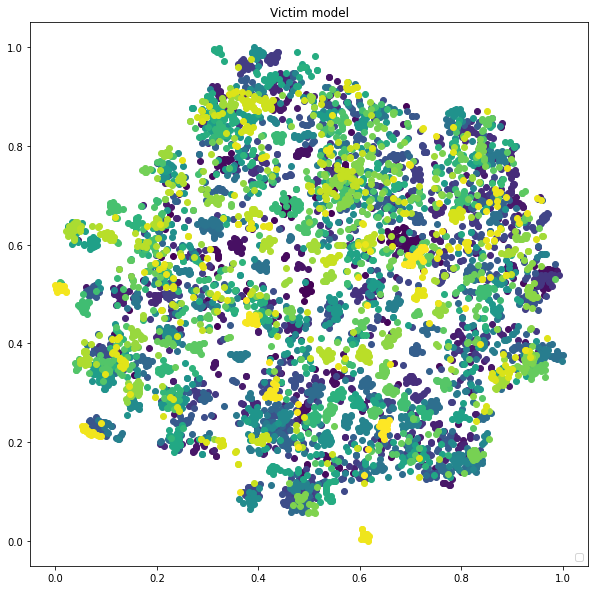

In [16]:
cmap = plt.get_cmap('viridis', num_classes)

# Victim model
tx_sub, ty_sub, y_test_sub = tx2, ty2, y_victim
tx_sub, ty_sub, y_test_sub = tx_sub[:M], ty_sub[:M], y_test_sub[:M]

fig = plt.figure(figsize=(10,10))
for i in range(num_classes):
    y_i = y_test_sub == i
    # plt.scatter(tx_sub[y_i[:]], ty_sub[y_i[:]], label=classes[i])
    plt.scatter(tx_sub[y_i[:]], ty_sub[y_i[:]], color=cmap(i / num_classes))

    
plt.title('Victim model')
plt.legend(loc=4)